<h1>ECON 140 Section 3</h1>

Today's teaching goals are:
- Construct and interpret confidence intervals for the population mean.


First, let's load the necessary libraries.

In [115]:
library(ggplot2)

Now we set the seed to make our results reproducible.

* Interactive question 1: Set your birth date as the random seed


In [116]:
set.seed(1234)

Confidence intervals: if we were to repeat the sampling and calculation of a mean over and over again (an infinite number of times), our confidence interval should include the true mean $(1-\alpha)$100% of the times

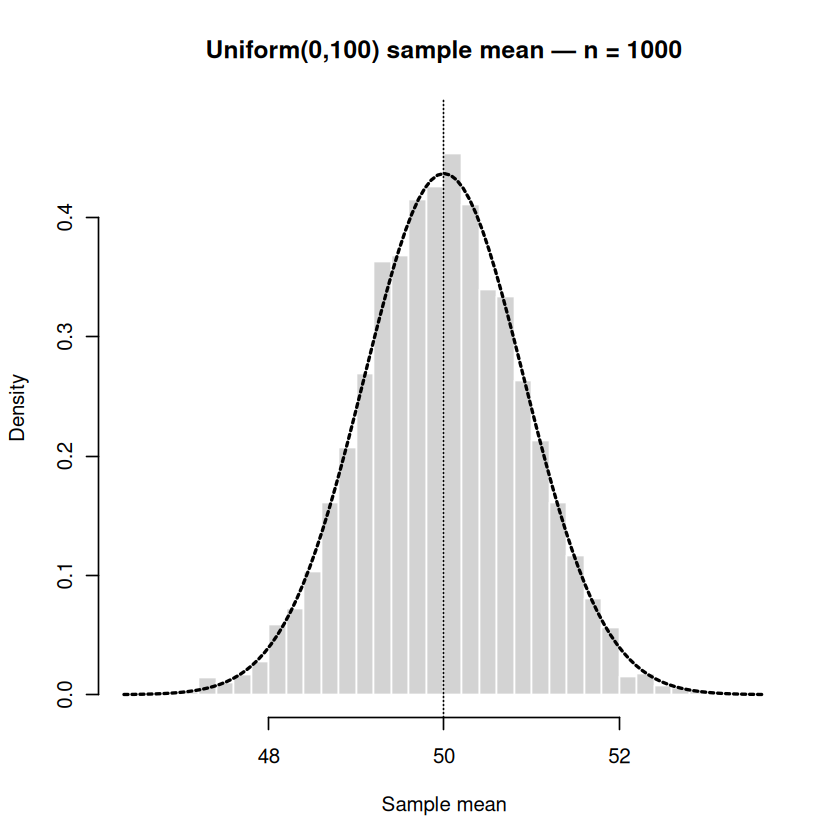

In [117]:
mu  <- 50
sigma <- 100/sqrt(12)
n = 1000
K <- 5000

means <- replicate(K, mean(runif(n, 0, 100)))

## Distribution of sample means
xlims <- mu + c(-4, 4) * sigma / sqrt(n)
dens_max <- dnorm(mu, mean=mu, sd=sigma/sqrt(n))
hist(means, probability=TRUE, border="white", xlim=xlims,
  ylim=c(0, 1.1*dens_max), breaks = 40,
  main=paste("Uniform(0,100) sample mean — n =", n),
  xlab="Sample mean")
curve(dnorm(x, mean=mu, sd=sigma/sqrt(n)), add=TRUE, lwd=2, lty=2)
abline(v=mu, lty=3)


* Interactive question 2: What distribution does this look like? What theorem describes this?
* Interactive question 3: What would happen if we let the sample size $n$ go to $\infty$?

In [149]:
# Let's suppose that test scores are normally distributed with mean = 75
# and standard deviation = 10.
pop_mean <- 75
pop_sd   <- 10

# We'll draw a random sample from the population for analysis.
n  <- 40
x  <- rnorm(n, mean = pop_mean, sd = pop_sd)

Let's calculate the mean and standard deviation of our sample.

In [150]:
mean(x); sd(x)

[1] 71.73311

[1] 10.51249

We will now construct confidence intervals for the population mean.

These intervals describe a range of values within which a population parameter (in this case, the population mean) is likely to lie.

In [151]:
# Null hypothesis is that population mean = 0
mu0 <- 0

# Set confidence levels
levels <- c(0.90, 0.95, 0.99)

# Create empty dataframe to store your results
results <- data.frame()

# Calculate the t-stat, p-value, and confidence interval
for (level in levels) {
 tt <- t.test(x, mu = mu0, conf.level = level)
 # store results
 row <- data.frame(
    level   = level,
    t_stat  = unname(tt$statistic),
    p_value = tt$p.value,
    lo      = tt$conf.int[1],
    hi      = tt$conf.int[2],
    width   = diff(tt$conf.int)
  )
  # Add to dataframe
  results <- rbind(results, row)
}

results

level,t_stat,p_value,lo,hi,width
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.90,43.15629,1.553949e-34,68.93256,74.53366,5.601099
0.95,43.15629,1.553949e-34,68.37105,75.09516,6.724113
0.99,43.15629,1.553949e-34,67.23209,76.23412,9.002025


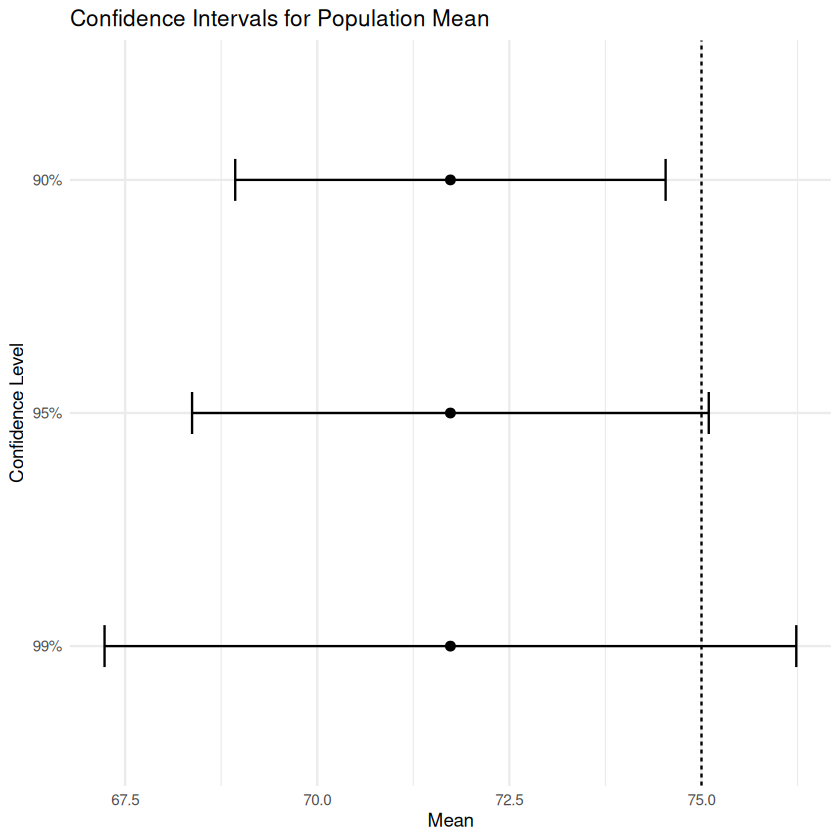

In [152]:
# Let's plot the confidence intervals using ggplot.

results$label <- paste0(results$level * 100, "%")
m <- mean(x) # sample mean
mu0 <- 75  # reference line for population mean

ggplot(results, aes(y = factor(label, levels = rev(unique(label))))) +
  geom_errorbarh(aes(xmin = lo, xmax = hi), height = 0.18) +
  geom_point(aes(x = m), size = 2) +
  geom_vline(xintercept = mu0, linetype = "dashed") +  # optional
  labs(x = "Mean", y = "Confidence Level",
       title = "Confidence Intervals for Population Mean") +
  theme_minimal()

More Questions:
- Interpret one of these confidence intervals in words. What does it tell us about our population parameter?
- Which interval is the most precise? Which is the least precise?
- What would happen to the confidence intervals if I doubled the sample size?
- If 10 people attend this class, how often do we get a significant result? What about 20 people? 100 people?

In [153]:
print("Thank you!")

[1] "Thank you!"
